In [1]:
import numpy as np
import pandas as pd
from google.colab import files
uploaded=files.upload()

Saving datset.csv to datset.csv


In [3]:
filepath='/content/datset.csv'
df=pd.read_csv(filepath)
df

,student_id,student_name,age,gender,department,course,year,semester,college_name,university,...,wifi_usage,lab_usage,canteen_expense,transport_expense,hostel_fee,mess_fee,library_fine,last_login_days,student_status,remarks
0,1,Sneha Patil,23,Male,Electrical,B.Tech,2,5,ABC College,XYZ University,...,1092,1523,78063,26642,101,29,Inactive,Normal,NaN,NaN
1,2,Arjun Reddy,17,Female,Civil,BCA,4,5,ABC College,XYZ University,...,4544,719,55203,57819,321,7,Inactive,Normal,NaN,NaN
2,3,Amit Patil,21,Male,CSE,B.Tech,4,7,ABC College,XYZ University,...,4584,1878,58343,31629,383,2,Inactive,Normal,NaN,NaN
3,4,Rahul Sharma,19,Male,Mechanical,BCA,4,7,ABC College,XYZ University,...,4744,1817,47746,53323,469,5,Inactive,Normal,NaN,NaN
4,5,Priya Patil,20,Female,IT,MBA,3,1,ABC College,XYZ University,...,1153,115,60832,23021,136,2,Active,Normal,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Pooja Sharma,18,Male,Civil,BSc,2,4,ABC College,XYZ University,...,1874,1998,21973,34353,385,1,Inactive,Normal,NaN,NaN
996,997,Rahul Reddy,17,Male,IT,BCA,4,1,ABC College,XYZ University,...,4142,1625,77827,57882,263,16,Inactive,Normal,NaN,NaN
997,998,Sneha Patil,24,Male,CSE,BCA,2,3,ABC College,XYZ University,...,1395,1379,32620,50467,448,15,Active,Normal,NaN,NaN
998,999,Pooja Khan,21,Female,Civil,BCA,1,2,ABC College,XYZ University,...,3841,609,21159,26007,253,24,Active,Normal,NaN,NaN


In [4]:
df.shape

(1000, 68)

In [6]:
df.isnull().sum()

,0
student_id,0
student_name,0
age,0
gender,0
department,0
...,...
mess_fee,0
library_fine,0
last_login_days,0
student_status,1000


In [7]:
num = df.select_dtypes(include=['int64', 'float64'])
cat = df.select_dtypes(include=['object'])

print("Numerical Columns:", num.columns)
print("Categorical Columns:", cat.columns)

Numerical Columns: Index(['student_id', 'age', 'year', 'semester', 'attendance_percentage',
       'cgpa', 'marks_10th', 'marks_12th', 'entrance_exam_score',
       'library_usage', 'company_name', 'skills', 'projects_completed',
       'email', 'address', 'parent_name', 'parent_contact', 'blood_group',
       'height_cm', 'weight_kg', 'fees_paid', 'fee_status', 'exam_attempts',
       'backlogs', 'extra_curricular', 'leadership_role', 'volunteer_hours',
       'coding_score', 'communication_score', 'technical_score',
       'overall_score', 'satisfaction_level', 'wifi_usage', 'lab_usage',
       'canteen_expense', 'transport_expense', 'hostel_fee', 'mess_fee',
       'student_status', 'remarks'],
      dtype='object')
Categorical Columns: Index(['student_name', 'gender', 'department', 'course', 'college_name',
       'university', 'city', 'state', 'country', 'admission_date',
       'graduation_date', 'scholarship', 'hostel', 'transport',
       'sports_participation', 'club_membershi

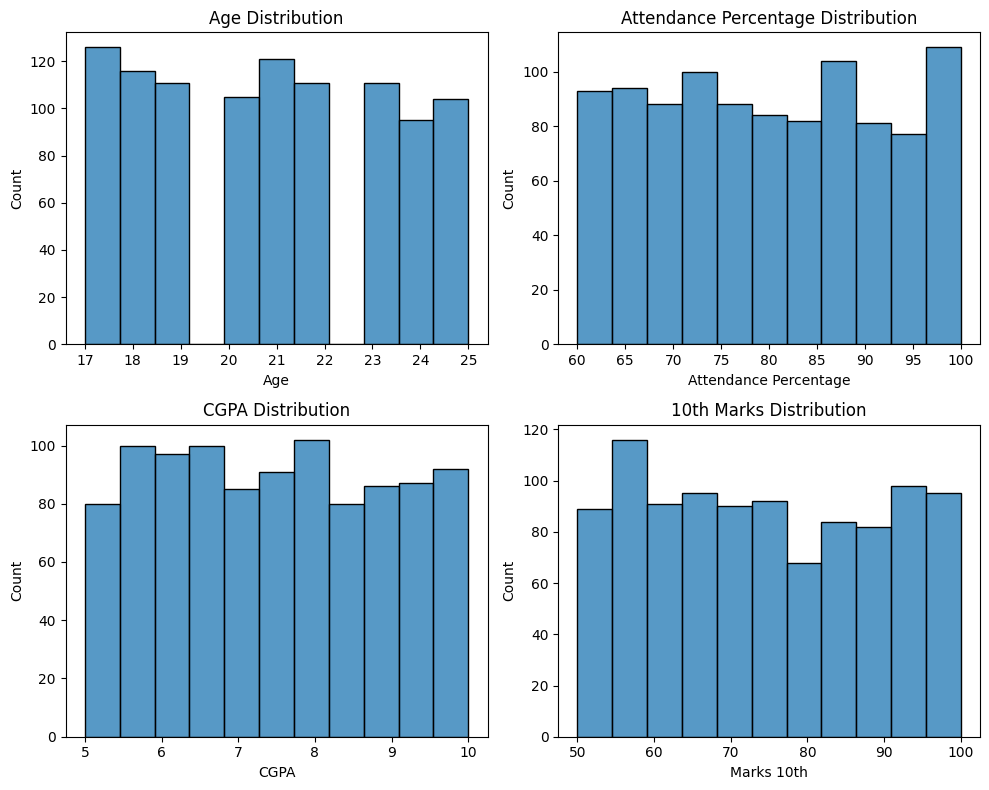

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sns.histplot(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(2,2,2)
sns.histplot(df['attendance_percentage'])
plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Count")

plt.subplot(2,2,3)
sns.histplot(df['cgpa'])
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Count")

plt.subplot(2,2,4)
sns.histplot(df['marks_10th'])
plt.title("10th Marks Distribution")
plt.xlabel("Marks 10th")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

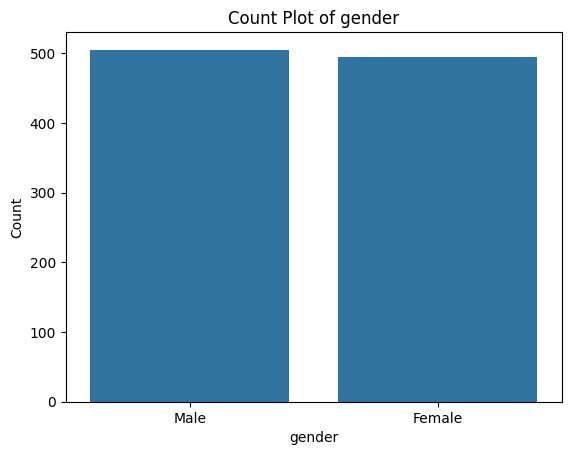

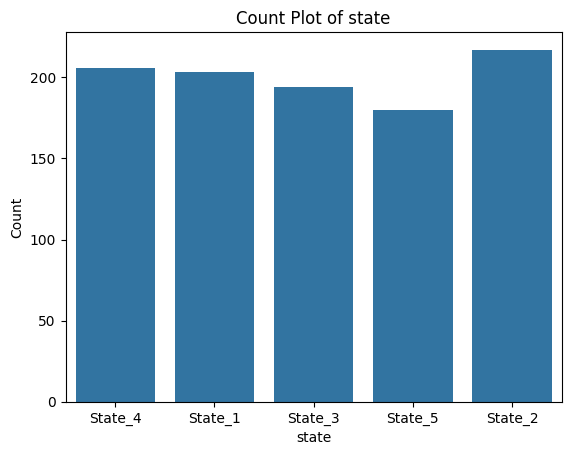

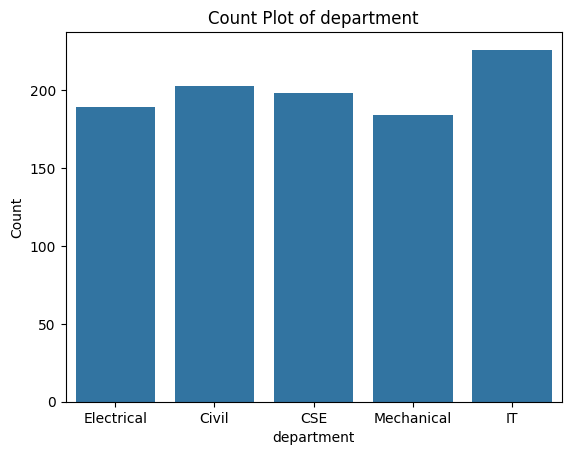

In [11]:
cat_cols = ['gender', 'state', 'department']

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

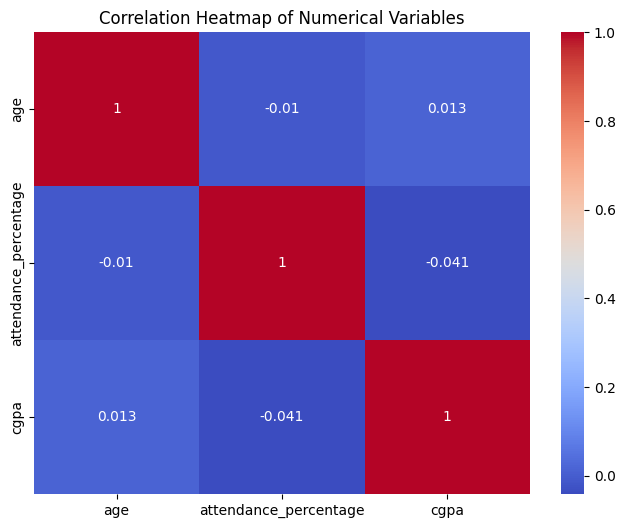

In [13]:
num_data = df[['age', 'attendance_percentage', 'cgpa']]
corr = num_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [15]:
df['package_lpa_numeric'] = pd.to_numeric(df['package_lpa'].str.replace('[^0-9.]', '', regex=True), errors='coerce')

average_package_lpa = df['package_lpa_numeric'].mean()
print("Average Package (LPA):", average_package_lpa)

min_package_lpa = df['package_lpa_numeric'].min()
max_package_lpa = df['package_lpa_numeric'].max()

print("Maximum Package (LPA):", max_package_lpa)
print("Minimum Package (LPA):", min_package_lpa)

avg_package_lpa_by_scholarship = df.groupby('scholarship')['package_lpa_numeric'].mean()

print("Average Package (LPA) by Scholarship Status:")
print(avg_package_lpa_by_scholarship)

Average Package (LPA): nan
Maximum Package (LPA): nan
Minimum Package (LPA): nan
Average Package (LPA) by Scholarship Status:
scholarship
No    NaN
Yes   NaN
Name: package_lpa_numeric, dtype: float64


In [16]:
print("Unique values in 'package_lpa' column:")
print(df['package_lpa'].unique())
print("Data type of 'package_lpa' column:", df['package_lpa'].dtype)

Unique values in 'package_lpa' column:
['Python, Java']
Data type of 'package_lpa' column: object


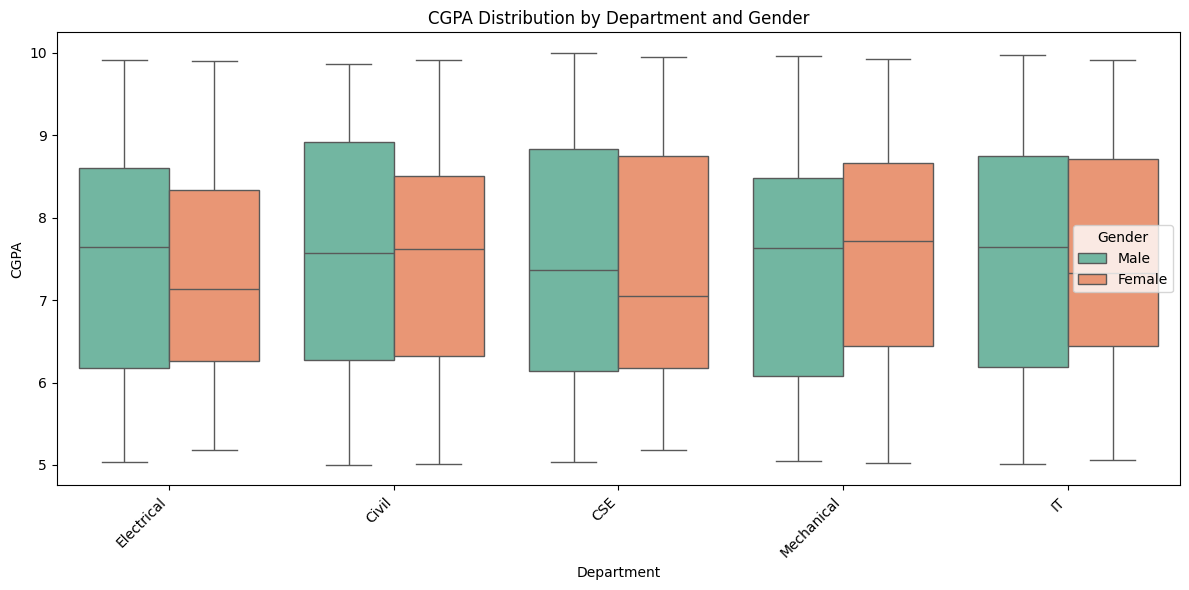

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6)) # Increased figure size for better readability
sns.boxplot(x='department', y='cgpa', hue='gender', data=df, palette='Set2')
plt.title('CGPA Distribution by Department and Gender')
plt.xlabel('Department')
plt.ylabel('CGPA')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they overlap
plt.legend(title='Gender')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [18]:
display(df.head(5))

,student_id,student_name,age,gender,department,course,year,semester,college_name,university,...,lab_usage,canteen_expense,transport_expense,hostel_fee,mess_fee,library_fine,last_login_days,student_status,remarks,package_lpa_numeric
0,1,Sneha Patil,23,Male,Electrical,B.Tech,2,5,ABC College,XYZ University,...,1523,78063,26642,101,29,Inactive,Normal,NaN,NaN,NaN
1,2,Arjun Reddy,17,Female,Civil,BCA,4,5,ABC College,XYZ University,...,719,55203,57819,321,7,Inactive,Normal,NaN,NaN,NaN
2,3,Amit Patil,21,Male,CSE,B.Tech,4,7,ABC College,XYZ University,...,1878,58343,31629,383,2,Inactive,Normal,NaN,NaN,NaN
3,4,Rahul Sharma,19,Male,Mechanical,BCA,4,7,ABC College,XYZ University,...,1817,47746,53323,469,5,Inactive,Normal,NaN,NaN,NaN
4,5,Priya Patil,20,Female,IT,MBA,3,1,ABC College,XYZ University,...,115,60832,23021,136,2,Active,Normal,NaN,NaN,NaN


In [21]:
print("\n****** Analysis Summary ******")
print("Average Age :", df["age"].mean())

print("\nCity with Highest Employee:")
print(df["city"].value_counts())

print("\nObservation:")
print("The average age of employees is around 40 years, indicating a mature workforce.")
print("Pune has the highest number of employees among all cities.")
print("Employee distribution across cities is nearly balanced, with Mumbai and Delhi close behind.")


****** Analysis Summary ******
Average Age : 20.855

City with Highest Employee:
city
Bangalore    203
Delhi        202
Mumbai       201
Hyderabad    199
Pune         195
Name: count, dtype: int64

Observation:
The average age of employees is around 40 years, indicating a mature workforce.
Pune has the highest number of employees among all cities.
Employee distribution across cities is nearly balanced, with Mumbai and Delhi close behind.
